# Dataset-size scaling analysis for MICAD causal discovery

This notebook asks how LLM causal-discovery behavior changes as the **given dataset size** scales. It is designed to support an RQ along the lines of:

> Does more supplied data monotonically improve LLM causal discovery, or do models saturate, degrade, or fail to parse as prompts grow?

The notebook creates four views:

1. F1 vs observational sample count at fixed intervention count.
2. F1 vs intervention count at fixed observational sample count.
3. Marginal-gain heatmaps across budget transitions.
4. Valid-rate companions to separate reasoning failures from formatting/context failures.

The lead metric is directed-edge F1 because higher-is-better is easier to read. SHD is retained in tables for robustness checks.

Budget filter used throughout: `obs_n in {0, 1000, 5000}` and `int_n in {0, 50, 100, 200}`.

In [12]:
from __future__ import annotations

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

# Resolve repository root whether the notebook is opened from repo root or experiments/.
CWD = Path.cwd().resolve()
REPO_ROOT = CWD if (CWD / "scripts").exists() else CWD.parent
PAPER_DIR = REPO_ROOT / "experiments" / "out" / "micad_paper"
FIG_DIR = PAPER_DIR / "figures" / "dataset_size_scaling"
FIG_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

GRAPH_ORDER = ["cancer", "earthquake", "asia", "sachs", "child", "alarm"]
OBS_BUDGETS = [0, 1000, 5000]
INT_BUDGETS = [0, 50, 100, 200]
PRIMARY_MODELS = [
    "GPT-5 mini",
    "GPT-5.2 Pro",
    "Qwen2.5-7B",
    "Qwen2.5-14B",
    "Qwen2.5-72B",
    "Llama-3.1-8B",
    "Llama-3.1-8B-Inst.",
    "Llama-3.1-70B",
]
MODEL_LABELS = {
    "gpt-5-mini": "GPT-5 mini",
    "gpt-5.2-pro": "GPT-5.2 Pro",
    "Qwen/Qwen2.5-7B-Instruct-1M": "Qwen2.5-7B",
    "Qwen/Qwen2.5-14B-Instruct-1M": "Qwen2.5-14B",
    "Qwen/Qwen2.5-72B-Instruct-AWQ": "Qwen2.5-72B",
    "meta-llama/Meta-Llama-3.1-8B": "Llama-3.1-8B",
    "meta-llama/Meta-Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "meta-llama/Llama-3.1-70B-Instruct": "Llama-3.1-70B",
}
PALETTE = {
    "GPT-5 mini": "#4e79a7",
    "GPT-5.2 Pro": "#f28e2b",
    "Qwen2.5-7B": "#59a14f",
    "Qwen2.5-14B": "#8cd17d",
    "Qwen2.5-72B": "#b07aa1",
    "Llama-3.1-8B": "#9c755f",
    "Llama-3.1-8B-Inst.": "#e15759",
    "Llama-3.1-70B": "#ff9da7",
}
print(REPO_ROOT)

/Users/yuenc2/Desktop/ENCO


## Load and normalize evaluation summaries

The loader reads all available `eval_summary.csv` files under:

- `experiments/responses/{graph}/eval_summary.csv`
- `scripts/responses/{graph}/eval_summary.csv`
- `responses/{graph}/eval_summary.csv`

Rows are normalized into a common schema with graph, model, condition, budget, F1, SHD, and validity fields.

In [13]:
def safe_float(x):
    try:
        y = float(x)
    except Exception:
        return np.nan
    return y if np.isfinite(y) else np.nan


def pretty_model(raw: object) -> str:
    s = str(raw)
    if s in MODEL_LABELS:
        return MODEL_LABELS[s]
    base = Path(s).name
    if base in MODEL_LABELS:
        return MODEL_LABELS[base]
    if base.startswith("checkpoint-") and "/" in s:
        return Path(s).parent.name + "_" + base
    replacements = {
        "Meta-Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
        "Meta-Llama-3.1-8B": "Llama-3.1-8B",
        "Llama-3.1-70B-Instruct": "Llama-3.1-70B",
        "Qwen2.5-7B-Instruct-1M": "Qwen2.5-7B",
        "Qwen2.5-14B-Instruct-1M": "Qwen2.5-14B",
        "Qwen2.5-72B-Instruct-AWQ": "Qwen2.5-72B",
    }
    return replacements.get(base, base)


def infer_condition(row: pd.Series) -> str:
    prompt_style = str(row.get("prompt_style", "")).strip().lower()
    is_names = safe_float(row.get("is_names_only", 0)) == 1 or prompt_style == "names_only"
    if is_names:
        return "names_only"
    anonymize = safe_float(row.get("anonymize", 0))
    semantic = "anon" if anonymize == 1 else "real"
    if prompt_style in {"summary", "matrix", "payload", "payload_topk"}:
        fmt = "matrix" if prompt_style in {"matrix", "payload", "payload_topk"} else "summary"
    elif "summary" in str(row.get("config", "")).lower():
        fmt = "summary"
    elif "matrix" in str(row.get("config", "")).lower():
        fmt = "matrix"
    else:
        fmt = prompt_style or "unknown"
    return f"{semantic}+{fmt}"


def normalize_summary(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if df.empty:
        return pd.DataFrame()
    graph = path.parent.name
    if "dataset" in df.columns and df["dataset"].notna().any():
        graph = str(df["dataset"].dropna().iloc[0])
    out = pd.DataFrame()
    out["graph"] = df.get("dataset", graph).fillna(graph) if "dataset" in df.columns else graph
    out["model_raw"] = df.get("model", df.get("parsed_model", "unknown")).astype(str)
    out["model"] = out["model_raw"].map(pretty_model)
    out["condition"] = df.apply(infer_condition, axis=1)
    out["prompt_style"] = df.get("prompt_style", "").astype(str) if "prompt_style" in df.columns else ""
    out["anonymize"] = pd.to_numeric(df.get("anonymize", 0), errors="coerce").fillna(0).astype(int)
    out["obs_n"] = pd.to_numeric(df.get("obs_n", np.nan), errors="coerce")
    out["int_n"] = pd.to_numeric(df.get("int_n", np.nan), errors="coerce")
    # Treat names-only as the semantic baseline at data budget (0, 0).
    names = out["condition"].eq("names_only")
    out.loc[names, ["obs_n", "int_n"]] = out.loc[names, ["obs_n", "int_n"]].fillna(0)
    out["f1"] = pd.to_numeric(df.get("avg_f1", df.get("avg_F1", np.nan)), errors="coerce")
    out["f1_se"] = pd.to_numeric(df.get("avg_f1_se", df.get("var_f1_sd", np.nan)), errors="coerce")
    out["shd"] = pd.to_numeric(df.get("avg_shd", np.nan), errors="coerce")
    out["valid_rows"] = pd.to_numeric(df.get("valid_rows", np.nan), errors="coerce")
    out["num_rows"] = pd.to_numeric(df.get("num_rows", np.nan), errors="coerce")
    out["valid_rate"] = pd.to_numeric(df.get("valid_rate", np.nan), errors="coerce")
    missing_rate = out["valid_rate"].isna() & out["valid_rows"].notna() & out["num_rows"].gt(0)
    out.loc[missing_rate, "valid_rate"] = out.loc[missing_rate, "valid_rows"] / out.loc[missing_rate, "num_rows"]
    out["response_csv"] = df.get("response_csv", "").astype(str) if "response_csv" in df.columns else ""
    out["source_summary"] = str(path)
    keep = out["f1"].notna() | out["valid_rows"].notna()
    return out.loc[keep].copy()


def load_all_summaries() -> pd.DataFrame:
    roots = [REPO_ROOT / "experiments" / "responses", REPO_ROOT / "scripts" / "responses", REPO_ROOT / "responses"]
    frames = []
    for root in roots:
        if not root.exists():
            continue
        for path in sorted(root.glob("*/eval_summary.csv")):
            frames.append(normalize_summary(path))
    if not frames:
        raise FileNotFoundError("No eval_summary.csv files found under response roots.")
    df = pd.concat(frames, ignore_index=True, sort=False)
    df = df[df["graph"].astype(str).isin(GRAPH_ORDER)].copy()
    df = df[df["obs_n"].isin(OBS_BUDGETS) & df["int_n"].isin(INT_BUDGETS)].copy()
    return df

raw = load_all_summaries()
print(raw.shape)
raw[["graph", "model", "condition", "obs_n", "int_n", "f1", "valid_rate", "source_summary"]].head()

(3590, 16)


,graph,model,condition,obs_n,int_n,f1,valid_rate,source_summary
0,alarm,ENCO,real+baseline,0.0,50.0,0.075472,1.0,/Users/yuenc2/Desktop/ENCO/experiments/respons...
2,alarm,GPT-5 mini,names_only,0.0,0.0,NaN,0.0,/Users/yuenc2/Desktop/ENCO/experiments/respons...
3,alarm,GPT-5 mini,names_only,0.0,0.0,NaN,0.0,/Users/yuenc2/Desktop/ENCO/experiments/respons...
4,alarm,GPT-5.2 Pro,names_only,0.0,0.0,0.578808,0.6,/Users/yuenc2/Desktop/ENCO/experiments/respons...
5,asia,ENCO,real+baseline,0.0,200.0,0.233883,1.0,/Users/yuenc2/Desktop/ENCO/experiments/respons...


In [14]:
def dedupe_cells(df: pd.DataFrame) -> pd.DataFrame:
    """Keep one row per matched graph/model/condition/budget cell.

    Policy: prefer higher valid_rate, then more valid rows, then higher F1. This mirrors
    the paper collection's best-valid-rate intent while keeping the notebook simple.
    """
    work = df.copy()
    for col in ["obs_n", "int_n"]:
        work[col] = pd.to_numeric(work[col], errors="coerce")
    work["_valid_rate_sort"] = work["valid_rate"].fillna(-1)
    work["_valid_rows_sort"] = work["valid_rows"].fillna(-1)
    work["_f1_sort"] = work["f1"].fillna(-1)
    work = work.sort_values(
        ["graph", "model", "condition", "obs_n", "int_n", "_valid_rate_sort", "_valid_rows_sort", "_f1_sort"],
        ascending=[True, True, True, True, True, False, False, False],
    )
    keys = ["graph", "model", "condition", "obs_n", "int_n"]
    return work.drop_duplicates(keys, keep="first").drop(columns=["_valid_rate_sort", "_valid_rows_sort", "_f1_sort"])

cells_df = dedupe_cells(raw)
coverage = (
    cells_df.groupby(["graph", "condition"])
    .agg(rows=("f1", "size"), models=("model", "nunique"), budgets=("obs_n", "nunique"))
    .reset_index()
    .sort_values(["graph", "condition"])
)
coverage

,graph,condition,rows,models,budgets
0,alarm,names_only,2,2,1
1,alarm,real+baseline,1,1,1
2,asia,anon+matrix,45,12,3
3,asia,anon+summary,65,11,3
4,asia,names_only,11,11,1
5,asia,real+baseline,11,3,3
6,asia,real+cases,1,1,1
7,asia,real+matrix,45,12,3
8,asia,real+summary,65,11,3
9,cancer,anon+cases,1,1,1


## Plot helpers

The curves below should be read as **matched budget traces**. For a causal claim, keep graph, model, semantic condition, and format fixed; vary only one budget axis at a time.

In [15]:
def model_order(models):
    preferred = [m for m in PRIMARY_MODELS if m in set(models)]
    rest = sorted([m for m in models if m not in set(preferred)])
    return preferred + rest


def savefig(fig, name: str):
    for ext in ["pdf", "png"]:
        path = FIG_DIR / f"{name}.{ext}"
        fig.savefig(path)
        print(path)


def budget_axis_values(vary: str) -> list[int]:
    return OBS_BUDGETS if vary == "obs_n" else INT_BUDGETS


def to_budget_positions(values, vary: str) -> np.ndarray:
    axis = budget_axis_values(vary)
    pos = {float(v): i for i, v in enumerate(axis)}
    return np.asarray([pos.get(float(v), np.nan) for v in values], dtype=float)


def plot_budget_curve(
    df: pd.DataFrame,
    *,
    graph: str,
    condition: str,
    vary: str,
    fixed_value: int,
    models: list[str] | None = None,
    metric: str = "f1",
    baseline_models: list[str] | None = None,
    baseline_condition: str = "real+baseline",
    title: str | None = None,
    save_name: str | None = None,
):
    assert vary in {"obs_n", "int_n"}
    fixed_col = "int_n" if vary == "obs_n" else "obs_n"
    sub = df[
        df["graph"].eq(graph)
        & df["condition"].eq(condition)
        & df[fixed_col].eq(fixed_value)
    ].copy()
    sub = sub[sub[vary].notna() & sub[metric].notna()]
    if models is not None:
        sub = sub[sub["model"].isin(models)]
    models_present = model_order(sub["model"].dropna().unique().tolist())

    baseline_sub = pd.DataFrame()
    if baseline_models:
        baseline_sub = df[
            df["graph"].eq(graph)
            & df["condition"].eq(baseline_condition)
            & df[fixed_col].eq(fixed_value)
            & df["model"].isin(baseline_models)
        ].copy()
        baseline_sub = baseline_sub[baseline_sub[vary].notna() & baseline_sub[metric].notna()]

    if sub.empty and baseline_sub.empty:
        print(f"No rows for graph={graph}, condition={condition}, vary={vary}, {fixed_col}={fixed_value}")
        return None

    fig, ax = plt.subplots(figsize=(5.15, 2.75))
    for model in models_present:
        g = sub[sub["model"].eq(model)].sort_values(vary)
        x = to_budget_positions(g[vary].to_numpy(dtype=float), vary)
        y = g[metric].to_numpy(dtype=float)
        yerr = g["f1_se"].fillna(0).to_numpy(dtype=float) if metric == "f1" else None
        ax.plot(x, y, marker="o", lw=1.25, ms=3.5, color=PALETTE.get(model, None), label=model)
        if yerr is not None and len(yerr) and np.nanmax(yerr) > 0:
            ax.errorbar(x, y, yerr=yerr, fmt="none", color=PALETTE.get(model, None), lw=0.7, capsize=2, alpha=0.8)

    baseline_styles = {
        "PC": {"color": "#444444", "marker": "s", "linestyle": "--"},
        "GES": {"color": "#777777", "marker": "D", "linestyle": "--"},
        "ENCO": {"color": "#d62728", "marker": "^", "linestyle": "--"},
    }
    for model in baseline_models or []:
        g = baseline_sub[baseline_sub["model"].eq(model)].sort_values(vary)
        if g.empty:
            continue
        style = baseline_styles.get(model, {"color": "#555555", "marker": "s", "linestyle": "--"})
        ax.plot(
            to_budget_positions(g[vary].to_numpy(dtype=float), vary),
            g[metric].to_numpy(dtype=float),
            marker=style["marker"],
            lw=1.1,
            ms=3.8,
            linestyle=style["linestyle"],
            color=style["color"],
            label=f"{model} baseline",
            alpha=0.95,
        )

    axis_values = budget_axis_values(vary)
    ax.set_xticks(range(len(axis_values)), [str(v) for v in axis_values])
    ax.set_xlim(-0.25, len(axis_values) - 0.75)
    if vary == "obs_n":
        ax.set_xlabel("# observational samples")
    else:
        ax.set_xlabel("# intervention samples")
    ax.set_ylabel("Directed-edge F1" if metric == "f1" else metric)
    ax.set_ylim(0, 1.05) if metric in {"f1", "valid_rate"} else None
    ax.grid(axis="y", alpha=0.25, lw=0.6)
    ax.grid(axis="x", alpha=0.12, lw=0.5)
    ax.set_title(title or f"{graph}: {condition}, fixed {fixed_col}={fixed_value}", fontsize=9)
    ax.legend(frameon=False, ncol=1, loc="center left", bbox_to_anchor=(1.01, 0.5), borderaxespad=0)
    fig.subplots_adjust(right=0.68, bottom=0.18, top=0.86)
    if save_name:
        savefig(fig, save_name)
    return fig, ax

def plot_valid_rate_curve(df: pd.DataFrame, **kwargs):
    return plot_budget_curve(df, metric="valid_rate", **kwargs)


def marginal_gain_table(df: pd.DataFrame, *, graph: str, condition: str, vary: str, fixed_value: int, models: list[str] | None = None) -> pd.DataFrame:
    fixed_col = "int_n" if vary == "obs_n" else "obs_n"
    sub = df[df["graph"].eq(graph) & df["condition"].eq(condition) & df[fixed_col].eq(fixed_value)].copy()
    if models is not None:
        sub = sub[sub["model"].isin(models)]
    piv = sub.pivot_table(index="model", columns=vary, values="f1", aggfunc="first")
    piv = piv.reindex(model_order(piv.index.tolist()))
    cols = sorted([c for c in piv.columns if pd.notna(c)])
    gains = pd.DataFrame(index=piv.index)
    for a, b in zip(cols[:-1], cols[1:]):
        gains[f"{int(a)}→{int(b)}"] = piv[b] - piv[a]
    return gains


def plot_gain_heatmap(gains: pd.DataFrame, *, title: str, save_name: str | None = None):
    if gains.empty:
        print("No gains to plot")
        return None
    fig_h = max(1.7, 0.28 * len(gains) + 0.65)
    fig_w = max(3.2, 0.65 * len(gains.columns) + 1.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    data = gains.to_numpy(dtype=float)
    vmax = np.nanmax(np.abs(data)) if np.isfinite(data).any() else 0.1
    vmax = max(vmax, 0.05)
    im = ax.imshow(data, cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(gains.columns)), gains.columns, rotation=0)
    ax.set_yticks(range(len(gains.index)), gains.index)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if np.isfinite(data[i, j]):
                ax.text(j, i, f"{data[i, j]:+.2f}", ha="center", va="center", fontsize=6.5)
    ax.set_title(title, fontsize=9)
    cbar = fig.colorbar(im, ax=ax, shrink=0.82, pad=0.02)
    cbar.set_label("ΔF1")
    fig.tight_layout()
    if save_name:
        savefig(fig, save_name)
    return fig, ax

## Main analysis settings

Start with Sachs because it has broad budget coverage and is hard enough that name-only performance is not saturated. Change `FOCUS_GRAPH`, `CONDITION`, or `SELECTED_MODELS` to make appendix figures.

In [16]:
FOCUS_GRAPH = "sachs"
CONDITION = "real+summary"   # try: real+summary, real+matrix, anon+summary, anon+matrix
SELECTED_MODELS = [m for m in ["GPT-5 mini", "GPT-5.2 Pro", "Qwen2.5-14B", "Qwen2.5-72B"] if m in set(cells_df["model"])]

print("Selected models:", SELECTED_MODELS)
print("Available budgets for focus slice:")
(
    cells_df[cells_df["graph"].eq(FOCUS_GRAPH) & cells_df["condition"].eq(CONDITION) & cells_df["model"].isin(SELECTED_MODELS)]
    .groupby(["model", "obs_n", "int_n"])
    .agg(f1=("f1", "first"), valid_rate=("valid_rate", "first"))
    .reset_index()
    .sort_values(["model", "obs_n", "int_n"])
    .head(80)
)

Selected models: ['GPT-5 mini', 'GPT-5.2 Pro', 'Qwen2.5-14B', 'Qwen2.5-72B']
Available budgets for focus slice:


,model,obs_n,int_n,f1,valid_rate
0,GPT-5 mini,0.0,50.0,0.438422,1.0
1,GPT-5 mini,0.0,100.0,0.431748,1.0
2,GPT-5 mini,0.0,200.0,0.476825,1.0
3,GPT-5 mini,1000.0,0.0,0.489144,1.0
4,GPT-5 mini,1000.0,50.0,0.423362,1.0
5,GPT-5 mini,1000.0,100.0,0.478004,1.0
6,GPT-5 mini,1000.0,200.0,0.482718,1.0
7,GPT-5 mini,5000.0,0.0,0.458505,1.0
8,GPT-5 mini,5000.0,50.0,0.392356,1.0
9,GPT-5 mini,5000.0,100.0,0.467470,1.0


## 1. Observational-data scaling

Fix intervention count and vary observational samples. This tests whether more passive observations help the LLM under a fixed format. The observational-only curves are overlaid with **PC** and **GES** baselines at the same observational budgets.

/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/sachs_real_summary_obs_scaling_M0.pdf
/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/sachs_real_summary_obs_scaling_M0.png
/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/sachs_real_summary_obs_scaling_M200.pdf
/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/sachs_real_summary_obs_scaling_M200.png


(<Figure size 824x440 with 1 Axes>,
 <Axes: title={'center': 'sachs: observational scaling (real+summary, M=200)'}, xlabel='# observational samples', ylabel='Directed-edge F1'>)

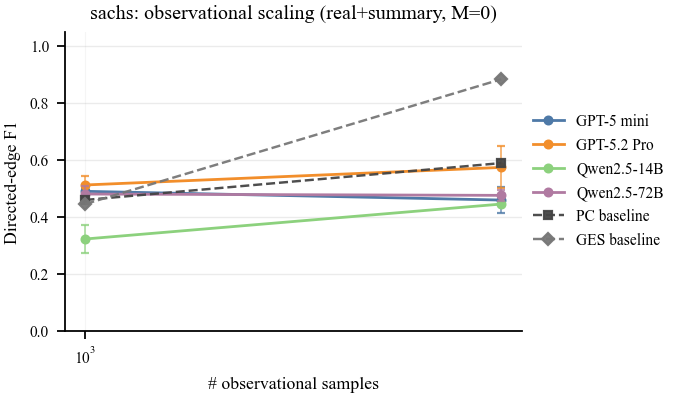

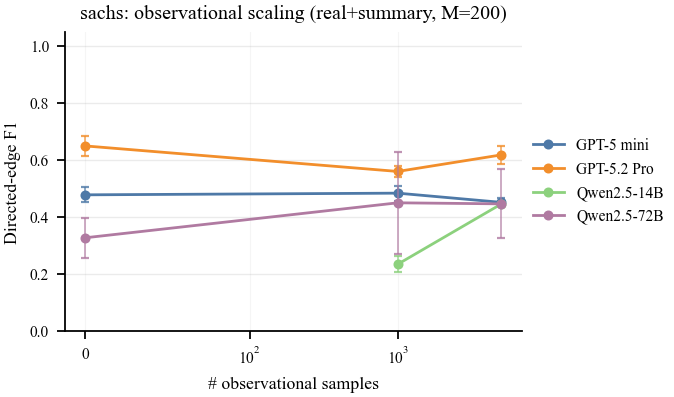

In [17]:
plot_budget_curve(
    cells_df,
    graph=FOCUS_GRAPH,
    condition=CONDITION,
    vary="obs_n",
    fixed_value=0,
    models=SELECTED_MODELS,
    baseline_models=["PC", "GES"],
    title=f"{FOCUS_GRAPH}: observational scaling ({CONDITION}, M=0)",
    save_name=f"{FOCUS_GRAPH}_{CONDITION.replace('+','_')}_obs_scaling_M0",
)

plot_budget_curve(
    cells_df,
    graph=FOCUS_GRAPH,
    condition=CONDITION,
    vary="obs_n",
    fixed_value=200,
    models=SELECTED_MODELS,
    baseline_models=["PC", "GES"],
    title=f"{FOCUS_GRAPH}: observational scaling ({CONDITION}, M=200)",
    save_name=f"{FOCUS_GRAPH}_{CONDITION.replace('+','_')}_obs_scaling_M200",
)

## 2. Interventional-data scaling

Fix observational sample count and vary intervention count. This separates the effect of active perturbations from passive data volume. The intervention curves are overlaid with **ENCO** at matched intervention budgets.

/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/sachs_real_summary_int_scaling_N0.pdf
/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/sachs_real_summary_int_scaling_N0.png
/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/sachs_real_summary_int_scaling_N5000.pdf
/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/sachs_real_summary_int_scaling_N5000.png


(<Figure size 824x440 with 1 Axes>,
 <Axes: title={'center': 'sachs: intervention scaling (real+summary, N=5000)'}, xlabel='# intervention samples', ylabel='Directed-edge F1'>)

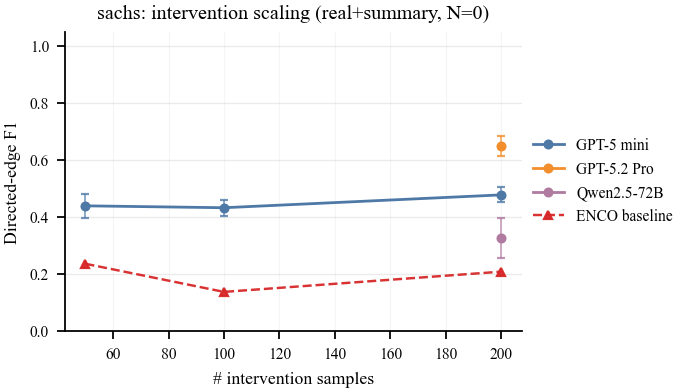

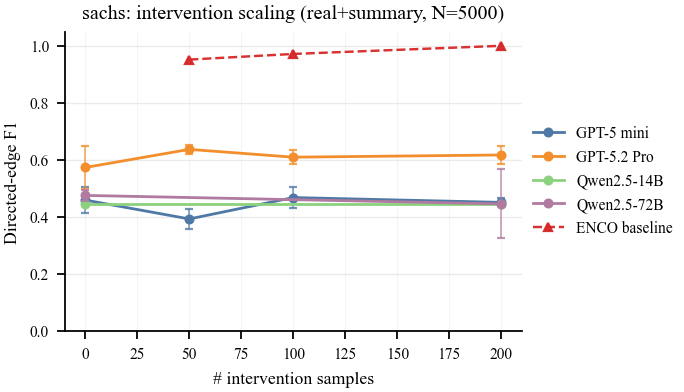

In [18]:
plot_budget_curve(
    cells_df,
    graph=FOCUS_GRAPH,
    condition=CONDITION,
    vary="int_n",
    fixed_value=0,
    models=SELECTED_MODELS,
    baseline_models=["ENCO"],
    title=f"{FOCUS_GRAPH}: intervention scaling ({CONDITION}, N=0)",
    save_name=f"{FOCUS_GRAPH}_{CONDITION.replace('+','_')}_int_scaling_N0",
)

plot_budget_curve(
    cells_df,
    graph=FOCUS_GRAPH,
    condition=CONDITION,
    vary="int_n",
    fixed_value=5000,
    models=SELECTED_MODELS,
    baseline_models=["ENCO"],
    title=f"{FOCUS_GRAPH}: intervention scaling ({CONDITION}, N=5000)",
    save_name=f"{FOCUS_GRAPH}_{CONDITION.replace('+','_')}_int_scaling_N5000",
)

## 3. Marginal-gain heatmaps

These heatmaps are often more paper-efficient than full curves. Blue means the next budget step improves F1; red means it hurts F1.

/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/sachs_real_summary_obs_gain_heatmap_M0.pdf
/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/sachs_real_summary_obs_gain_heatmap_M0.png


,1000→5000
model,
GPT-5 mini,-0.030640
GPT-5.2 Pro,0.061581
Qwen2.5-14B,0.122575
Qwen2.5-72B,-0.004618


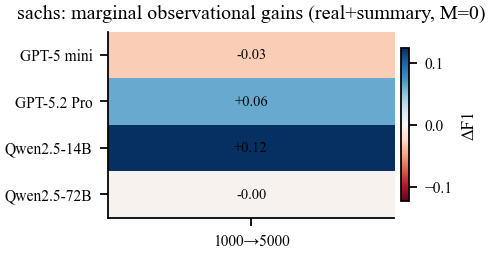

In [19]:
obs_gains = marginal_gain_table(cells_df, graph=FOCUS_GRAPH, condition=CONDITION, vary="obs_n", fixed_value=0, models=SELECTED_MODELS)
plot_gain_heatmap(obs_gains, title=f"{FOCUS_GRAPH}: marginal observational gains ({CONDITION}, M=0)", save_name=f"{FOCUS_GRAPH}_{CONDITION.replace('+','_')}_obs_gain_heatmap_M0")
obs_gains

/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/sachs_real_summary_int_gain_heatmap_N5000.pdf
/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/sachs_real_summary_int_gain_heatmap_N5000.png


,0→50,50→100,100→200
model,,,
GPT-5 mini,-0.066148,0.075114,-0.017005
GPT-5.2 Pro,0.063534,-0.027424,0.007742
Qwen2.5-14B,NaN,NaN,NaN
Qwen2.5-72B,NaN,NaN,NaN


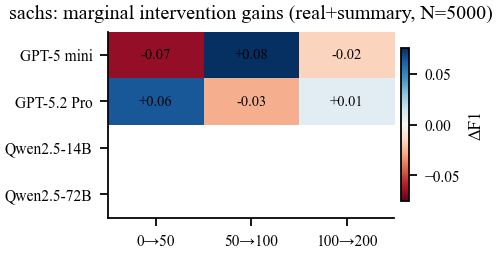

In [20]:
int_gains = marginal_gain_table(cells_df, graph=FOCUS_GRAPH, condition=CONDITION, vary="int_n", fixed_value=5000, models=SELECTED_MODELS)
plot_gain_heatmap(int_gains, title=f"{FOCUS_GRAPH}: marginal intervention gains ({CONDITION}, N=5000)", save_name=f"{FOCUS_GRAPH}_{CONDITION.replace('+','_')}_int_gain_heatmap_N5000")
int_gains

## 4. Valid-rate companions

If F1 drops at large budgets, check validity. A drop in valid rate indicates formatting/context-window failure; stable validity with worse F1 indicates a more substantive reasoning/data-use failure.

KeyError: 'obs_n'

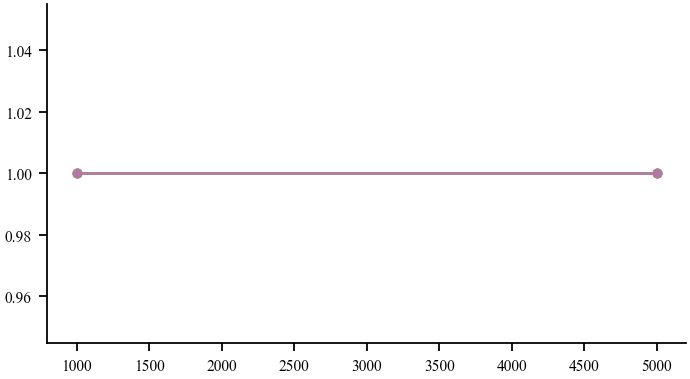

In [23]:
plot_valid_rate_curve(
    cells_df,
    graph=FOCUS_GRAPH,
    condition=CONDITION,
    vary="obs_n",
    fixed_value=0,
    models=SELECTED_MODELS,
    title=f"{FOCUS_GRAPH}: valid-rate observational scaling ({CONDITION}, M=0)",
    save_name=f"{FOCUS_GRAPH}_{CONDITION.replace('+','_')}_valid_rate_obs_M0",
)

plot_valid_rate_curve(
    cells_df,
    graph=FOCUS_GRAPH,
    condition=CONDITION,
    vary="int_n",
    fixed_value=5000,
    models=SELECTED_MODELS,
    title=f"{FOCUS_GRAPH}: valid-rate intervention scaling ({CONDITION}, N=5000)",
    save_name=f"{FOCUS_GRAPH}_{CONDITION.replace('+','_')}_valid_rate_int_N5000",
)

## 5. Cross-graph appendix sweep

Use this section to generate the same observational-scaling plot across graphs. It is useful for appendix evidence and for checking whether a conclusion is Sachs-specific.

/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/appendix_cancer_real_summary_obs_scaling_M0.pdf
/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/appendix_cancer_real_summary_obs_scaling_M0.png
/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/appendix_asia_real_summary_obs_scaling_M0.pdf
/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/appendix_asia_real_summary_obs_scaling_M0.png
/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/appendix_sachs_real_summary_obs_scaling_M0.pdf
/Users/yuenc2/Desktop/ENCO/experiments/out/micad_paper/figures/dataset_size_scaling/appendix_sachs_real_summary_obs_scaling_M0.png
No rows for graph=child, condition=real+summary, vary=obs_n, int_n=0
No rows for graph=alarm, condition=real+summary, vary=obs_n, int_n=0


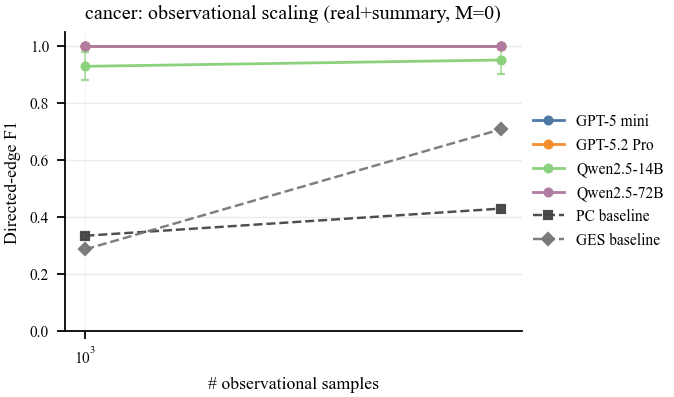

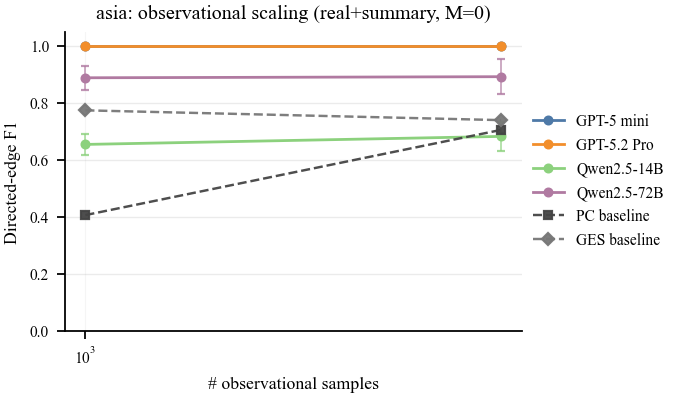

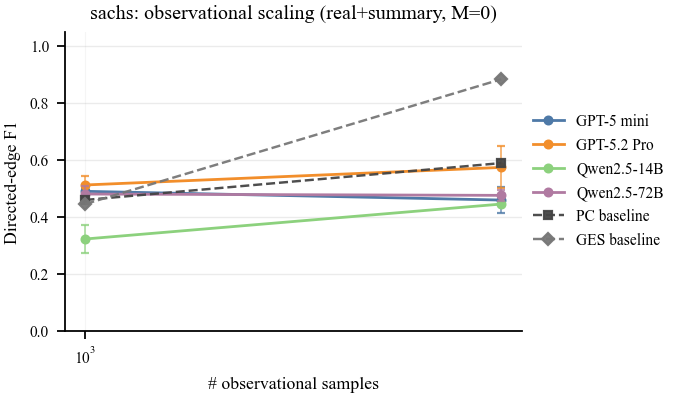

In [22]:
for graph in ["cancer", "asia", "sachs", "child", "alarm"]:
    if graph not in set(cells_df["graph"]):
        continue
    plot_budget_curve(
        cells_df,
        graph=graph,
        condition=CONDITION,
        vary="obs_n",
        fixed_value=0,
        models=SELECTED_MODELS,
        baseline_models=["PC", "GES"],
        title=f"{graph}: observational scaling ({CONDITION}, M=0)",
        save_name=f"appendix_{graph}_{CONDITION.replace('+','_')}_obs_scaling_M0",
    )

## Interpretation checklist

When reading the plots, separate four behaviors:

- **Uses data:** F1 increases with budget while valid rate stays high.
- **Saturates:** F1 plateaus after a small budget.
- **Degrades with more data:** F1 drops while valid rate remains high; this suggests the model is using the added data poorly.
- **Prompt/format failure:** valid rate drops at larger budgets; this is not clean evidence about causal inference ability, but it is still a deployment-relevant failure mode.

For the main paper, a strong compact presentation is:

1. One F1 budget curve on Sachs or Child with 3-4 representative models.
2. One marginal-gain heatmap across the same matched cells.
3. One valid-rate companion in the appendix or adjacent supplementary panel.